# NextQA Frame Selection Comparison

This notebook compares two frame-selection methods:
- `outputs/nextqa/nextqa_keyframes`
- `outputs/nextqa/nextqa_temporal_chain_keyframes`


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path('outputs/nextqa')
DIR_A = BASE_DIR / 'nextqa_keyframes'
DIR_B = BASE_DIR / 'nextqa_temporal_chain_keyframes'

assert DIR_A.exists(), f'Missing folder: {DIR_A}'
assert DIR_B.exists(), f'Missing folder: {DIR_B}'

print('Method A:', DIR_A)
print('Method B:', DIR_B)


Method A: outputs/nextqa/nextqa_keyframes
Method B: outputs/nextqa/nextqa_temporal_chain_keyframes


In [2]:
def load_method(folder: Path) -> dict:
    data = {}
    for fp in sorted(folder.glob('*.json')):
        obj = json.loads(fp.read_text())
        if len(obj) != 1:
            continue
        qid, pairs = next(iter(obj.items()))
        frame_indices = [int(x[0]) for x in pairs]
        ranks = [int(x[1]) for x in pairs]
        data[str(qid)] = {
            'frames': frame_indices,
            'ranks': ranks,
            'k': len(frame_indices),
        }
    return data

A = load_method(DIR_A)
B = load_method(DIR_B)

ids_a = set(A)
ids_b = set(B)
common_ids = sorted(ids_a & ids_b)
only_a = sorted(ids_a - ids_b)
only_b = sorted(ids_b - ids_a)

print(f'Method A samples: {len(ids_a):,}')
print(f'Method B samples: {len(ids_b):,}')
print(f'Common samples:   {len(common_ids):,}')
print(f'Only A samples:   {len(only_a):,}')
print(f'Only B samples:   {len(only_b):,}')


Method A samples: 4,996
Method B samples: 1,385
Common samples:   1,385
Only A samples:   3,611
Only B samples:   0


In [3]:
def metrics_for_id(qid: str, topk: int = 12) -> dict:
    a = A[qid]['frames'][:topk]
    b = B[qid]['frames'][:topk]

    set_a, set_b = set(a), set(b)
    inter = len(set_a & set_b)
    union = len(set_a | set_b)

    pos_a = {f: i for i, f in enumerate(a)}
    pos_b = {f: i for i, f in enumerate(b)}
    shared = sorted(set_a & set_b)

    rank_diff = np.mean([abs(pos_a[f] - pos_b[f]) for f in shared]) if shared else np.nan

    return {
        'qid': qid,
        'k_a': len(a),
        'k_b': len(b),
        'overlap_count': inter,
        'jaccard': inter / union if union else np.nan,
        'overlap_ratio_a': inter / len(a) if len(a) else np.nan,
        'overlap_ratio_b': inter / len(b) if len(b) else np.nan,
        'mean_abs_rank_diff_shared': rank_diff,
    }

df = pd.DataFrame(metrics_for_id(qid, topk=12) for qid in common_ids)
df.head()


,qid,k_a,k_b,overlap_count,jaccard,overlap_ratio_a,overlap_ratio_b,mean_abs_rank_diff_shared
0,100017877251,12,12,0,0.000000,0.000000,0.000000,NaN
1,100017877254,12,12,0,0.000000,0.000000,0.000000,NaN
2,100017877256,12,12,0,0.000000,0.000000,0.000000,NaN
3,100306099341,12,12,1,0.043478,0.083333,0.083333,3.0
4,100306099342,12,12,1,0.043478,0.083333,0.083333,1.0


In [4]:
summary = df[['overlap_count', 'jaccard', 'overlap_ratio_a', 'overlap_ratio_b', 'mean_abs_rank_diff_shared']].describe().T
summary


,count,mean,std,min,25%,50%,75%,max
overlap_count,1385.0,0.992780,1.049335,0.0,0.0,1.000000,2.000000,5.000000
jaccard,1385.0,0.045434,0.050182,0.0,0.0,0.043478,0.090909,0.263158
overlap_ratio_a,1385.0,0.082732,0.087445,0.0,0.0,0.083333,0.166667,0.416667
overlap_ratio_b,1385.0,0.082732,0.087445,0.0,0.0,0.083333,0.166667,0.416667
mean_abs_rank_diff_shared,830.0,4.075422,2.455221,0.0,2.0,4.000000,6.000000,11.000000


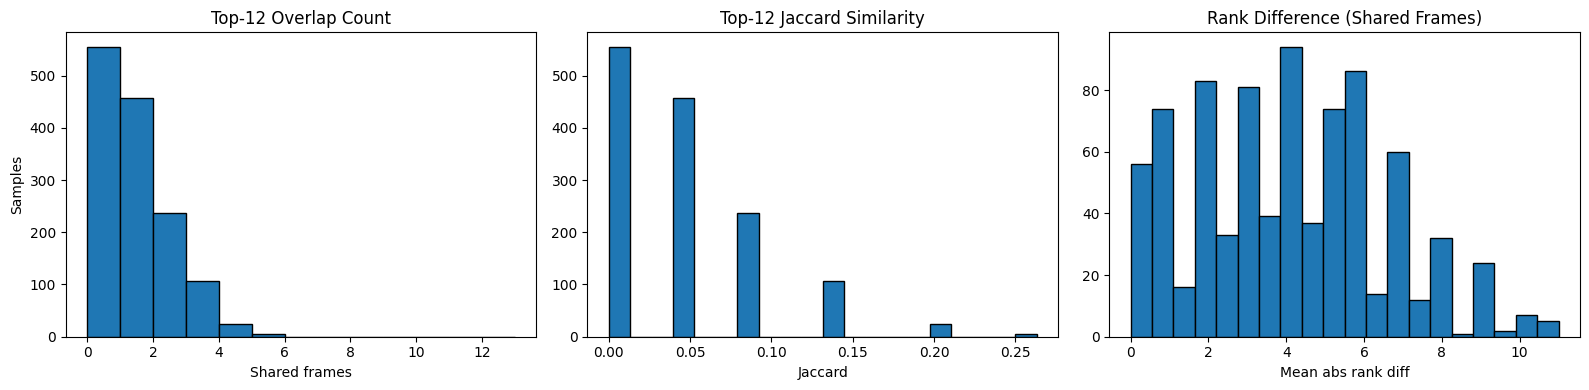

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['overlap_count'].dropna(), bins=range(0, 14), edgecolor='black')
axes[0].set_title('Top-12 Overlap Count')
axes[0].set_xlabel('Shared frames')
axes[0].set_ylabel('Samples')

axes[1].hist(df['jaccard'].dropna(), bins=20, edgecolor='black')
axes[1].set_title('Top-12 Jaccard Similarity')
axes[1].set_xlabel('Jaccard')

axes[2].hist(df['mean_abs_rank_diff_shared'].dropna(), bins=20, edgecolor='black')
axes[2].set_title('Rank Difference (Shared Frames)')
axes[2].set_xlabel('Mean abs rank diff')

plt.tight_layout()
plt.show()


In [6]:
# Inspect strongest / weakest agreement examples
best = df.sort_values(['jaccard', 'overlap_count'], ascending=False).head(10)
worst = df.sort_values(['jaccard', 'overlap_count'], ascending=True).head(10)

print('Best agreement samples:')
display(best[['qid', 'overlap_count', 'jaccard', 'mean_abs_rank_diff_shared']])
print('\nWorst agreement samples:')
display(worst[['qid', 'overlap_count', 'jaccard', 'mean_abs_rank_diff_shared']])


Best agreement samples:


,qid,overlap_count,jaccard,mean_abs_rank_diff_shared
86,24011677407,5,0.263158,3.80
744,48969696170,5,0.263158,3.40
745,48969696179,5,0.263158,5.40
1189,76911729220,5,0.263158,3.00
1190,76911729221,5,0.263158,4.00
66,132960541832,4,0.200000,3.25
161,27162779607,4,0.200000,3.50
180,27823070490,4,0.200000,3.25
181,27823070491,4,0.200000,3.25
182,27823070492,4,0.200000,2.75



Worst agreement samples:


,qid,overlap_count,jaccard,mean_abs_rank_diff_shared
0,100017877251,0,0.0,NaN
1,100017877254,0,0.0,NaN
2,100017877256,0,0.0,NaN
18,103095422553,0,0.0,NaN
19,105975338854,0,0.0,NaN
20,105975338856,0,0.0,NaN
21,106070959366,0,0.0,NaN
22,107276961432,0,0.0,NaN
23,107276961433,0,0.0,NaN
24,107276961434,0,0.0,NaN


In [7]:
# Optional: inspect exact frame lists for a specific question ID
sample_qid = common_ids[0] if common_ids else None
print('sample_qid =', sample_qid)
if sample_qid is not None:
    print('Method A frames:', A[sample_qid]['frames'])
    print('Method B frames:', B[sample_qid]['frames'])


sample_qid = 100017877251
Method A frames: [649, 504, 826, 590, 408, 154, 777, 46, 336, 417, 721, 222]
Method B frames: [802, 724, 312, 921, 619, 474, 876, 402, 105, 14, 536, 207]


## Answer Difference Analysis

This section compares answer outputs from:
- `outputs/nextqa/nextqa_ktv_token_only_uniform_token_tokens1872.json`
- `outputs/nextqa/temporal_chain/20260521T050745Z_pid1009647/predictions.json`


In [ ]:
import re

ANSWER_PATH_A = Path('outputs/nextqa/nextqa_ktv_token_only_uniform_token_tokens1872.json')
ANSWER_PATH_B = Path('outputs/nextqa/temporal_chain/20260521T050745Z_pid1009647/predictions.json')
ANSWER_LABEL_A = 'token_only'
ANSWER_LABEL_B = 'temporal_chain'


def load_prediction_records(path: Path) -> dict:
    text = path.read_text().strip()
    if not text:
        return {}

    try:
        payload = json.loads(text)
        if isinstance(payload, list):
            items = payload
        elif isinstance(payload, dict) and isinstance(payload.get('predictions'), list):
            items = payload['predictions']
        else:
            items = [payload]
    except json.JSONDecodeError:
        items = [json.loads(line) for line in text.splitlines() if line.strip()]

    return {
        str(item.get('question_id') or item.get('id')): item
        for item in items
        if item.get('question_id') is not None or item.get('id') is not None
    }


def normalize_answer_text(value: str | None) -> str | None:
    if value is None:
        return None
    value = re.sub(r'\s+', ' ', str(value).strip())
    value = value.rstrip(' .')
    return value.lower()


def extract_choice_letter(value: str | None) -> str | None:
    if not value:
        return None
    match = re.match(r'^\s*([A-E])\s*[\)\].:-]?', str(value), flags=re.I)
    return match.group(1).upper() if match else None


def canonicalize_prediction(pred: str | None, candidates: list[str]) -> dict:
    pred_raw = '' if pred is None else str(pred).strip()
    pred_letter = extract_choice_letter(pred_raw)
    pred_idx = None
    pred_text = pred_raw

    if pred_letter is not None:
        pred_idx = ord(pred_letter) - ord('A')
        if 0 <= pred_idx < len(candidates):
            pred_text = candidates[pred_idx]
    elif pred_raw:
        pred_text = re.sub(r'^\s*[A-E]\s*[\)\].:-]?\s*', '', pred_raw, flags=re.I)

    pred_norm = normalize_answer_text(pred_text)
    candidate_norms = [normalize_answer_text(candidate) for candidate in candidates]
    if pred_idx is None and pred_norm in candidate_norms:
        pred_idx = candidate_norms.index(pred_norm)

    return {
        'pred_raw': pred_raw,
        'pred_letter': pred_letter,
        'pred_idx': pred_idx,
        'pred_text': pred_text,
        'pred_norm': pred_norm,
    }


def resolve_gold(item: dict, candidates: list[str]) -> tuple[int | None, str | None]:
    gold_idx = item.get('answer_number')
    if gold_idx is not None:
        gold_idx = int(gold_idx)
    else:
        gold_norm = normalize_answer_text(item.get('answer'))
        candidate_norms = [normalize_answer_text(candidate) for candidate in candidates]
        if gold_norm in candidate_norms:
            gold_idx = candidate_norms.index(gold_norm)

    gold_text = candidates[gold_idx] if gold_idx is not None and 0 <= gold_idx < len(candidates) else item.get('answer')
    return gold_idx, gold_text


records_a = load_prediction_records(ANSWER_PATH_A)
records_b = load_prediction_records(ANSWER_PATH_B)
common_answer_ids = sorted(set(records_a) & set(records_b))

answer_rows = []
for qid in common_answer_ids:
    item_a = records_a[qid]
    item_b = records_b[qid]
    item_ref = item_a if item_a.get('candidates') else item_b

    candidates = item_ref.get('candidates') or []
    gold_idx, gold_text = resolve_gold(item_ref, candidates)
    parsed_a = canonicalize_prediction(item_a.get('pred'), candidates)
    parsed_b = canonicalize_prediction(item_b.get('pred'), candidates)

    correct_a = parsed_a['pred_idx'] == gold_idx if gold_idx is not None else None
    correct_b = parsed_b['pred_idx'] == gold_idx if gold_idx is not None else None

    answer_rows.append({
        'qid': qid,
        'question': item_ref.get('question'),
        'candidates': candidates,
        'gold_idx': gold_idx,
        'gold_text': gold_text,
        f'{ANSWER_LABEL_A}_pred_raw': parsed_a['pred_raw'],
        f'{ANSWER_LABEL_A}_pred_idx': parsed_a['pred_idx'],
        f'{ANSWER_LABEL_A}_pred_text': parsed_a['pred_text'],
        f'{ANSWER_LABEL_A}_correct': correct_a,
        f'{ANSWER_LABEL_B}_pred_raw': parsed_b['pred_raw'],
        f'{ANSWER_LABEL_B}_pred_idx': parsed_b['pred_idx'],
        f'{ANSWER_LABEL_B}_pred_text': parsed_b['pred_text'],
        f'{ANSWER_LABEL_B}_correct': correct_b,
        'same_choice': parsed_a['pred_idx'] == parsed_b['pred_idx'],
        'same_text': normalize_answer_text(parsed_a['pred_text']) == normalize_answer_text(parsed_b['pred_text']),
        'flipped_to_correct': (correct_a is False) and (correct_b is True),
        'flipped_to_wrong': (correct_a is True) and (correct_b is False),
    })

answers_df = pd.DataFrame(answer_rows)
print(f'Loaded {len(records_a):,} predictions from A and {len(records_b):,} from B')
print(f'Common question IDs: {len(common_answer_ids):,}')
answers_df.head()


In [ ]:
answer_summary = pd.DataFrame([
    {'metric': 'common_questions', 'value': len(answers_df)},
    {'metric': 'same_choice_count', 'value': int(answers_df['same_choice'].sum())},
    {'metric': 'different_choice_count', 'value': int((~answers_df['same_choice']).sum())},
    {'metric': f'{ANSWER_LABEL_A}_accuracy', 'value': answers_df[f'{ANSWER_LABEL_A}_correct'].mean()},
    {'metric': f'{ANSWER_LABEL_B}_accuracy', 'value': answers_df[f'{ANSWER_LABEL_B}_correct'].mean()},
    {'metric': 'improved_count_b_over_a', 'value': int(answers_df['flipped_to_correct'].sum())},
    {'metric': 'regressed_count_b_over_a', 'value': int(answers_df['flipped_to_wrong'].sum())},
])

outcome_breakdown = (
    answers_df
    .groupby([f'{ANSWER_LABEL_A}_correct', f'{ANSWER_LABEL_B}_correct'])
    .size()
    .rename('count')
    .reset_index()
    .sort_values('count', ascending=False)
)

display(answer_summary)
display(outcome_breakdown)


In [ ]:
changed_answers = answers_df.loc[~answers_df['same_choice']].copy()
improved_answers = changed_answers.loc[changed_answers['flipped_to_correct']].copy()
regressed_answers = changed_answers.loc[changed_answers['flipped_to_wrong']].copy()
changed_but_both_wrong = changed_answers.loc[
    ~changed_answers[f'{ANSWER_LABEL_A}_correct'] & ~changed_answers[f'{ANSWER_LABEL_B}_correct']
].copy()

cols = [
    'qid',
    'question',
    'gold_text',
    f'{ANSWER_LABEL_A}_pred_raw',
    f'{ANSWER_LABEL_B}_pred_raw',
    f'{ANSWER_LABEL_A}_correct',
    f'{ANSWER_LABEL_B}_correct',
]

print('Examples where B fixes an A mistake:')
display(improved_answers[cols].head(20))

print('\nExamples where B changes a correct A answer into a wrong one:')
display(regressed_answers[cols].head(20))

print('\nExamples where both are wrong but choose different answers:')
display(changed_but_both_wrong[cols].head(20))
